In [1]:
# ================================
# CUSTOMER CHURN PREDICTION PROJECT
# ================================

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported.")

Libraries imported.


In [2]:
# 2. Load Dataset
df = pd.read_csv('Your_dataset.csv')  
print("Dataset loaded successfully!")
print(df.head())

Dataset loaded successfully!
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV Streami


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-

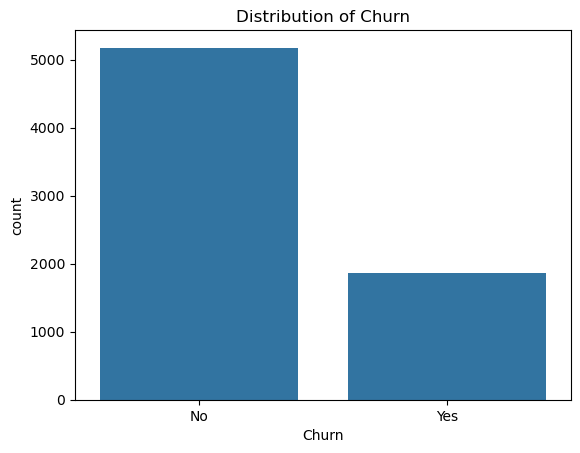

In [3]:
# 3. Initial Exploration
print("\nDataset info:")
df.info()
print("\nSummary statistics:")
print(df.describe())
print("\nTarget distribution:")
print(df['Churn'].value_counts())

sns.countplot(x='Churn', data=df)
plt.title('Distribution of Churn')
plt.show()

In [4]:
# 4. Handle Missing Values
if 'TotalCharges' in df.columns:
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

print("\nMissing values after handling:")
print(df.isnull().sum())


Missing values after handling:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [5]:
# 5. Feature Engineering
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

bins = [0, 12, 24, 36, 48, 60, np.inf]
labels = ['0-12 Months','13-24 Months','25-36 Months','37-48 Months','49-60 Months','60+ Months']
if 'tenure' in df.columns:
    df['Tenure_Group'] = pd.cut(df['tenure'], bins=bins, labels=labels, right=False)
    df = pd.get_dummies(df, columns=['Tenure_Group'], drop_first=True)

# Encode categorical variables
for col in df.select_dtypes(include='object').columns:
    if col != 'Churn':
        df[col] = LabelEncoder().fit_transform(df[col])

# Encode target
df['Churn'] = LabelEncoder().fit_transform(df['Churn'])


In [6]:
# 6. Train-Test Split
X = df.drop('Churn', axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [7]:
# 7. Initialize & Train Models
logistic_regression = LogisticRegression(random_state=42)
random_forest = RandomForestClassifier(random_state=42)
gradient_boosting = GradientBoostingClassifier(random_state=42)

logistic_regression.fit(X_train, y_train)
random_forest.fit(X_train, y_train)
gradient_boosting.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)


--- Logistic Regression ---
Accuracy: 0.7908187411263606
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.88      0.86      1552
           1       0.62      0.55      0.58       561

    accuracy                           0.79      2113
   macro avg       0.73      0.71      0.72      2113
weighted avg       0.78      0.79      0.79      2113



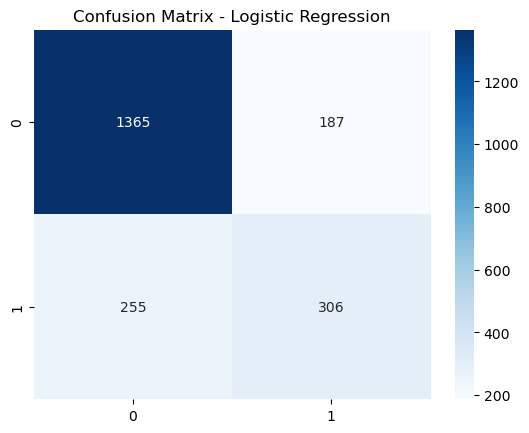


--- Random Forest ---
Accuracy: 0.7856128726928537
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.89      0.86      1552
           1       0.62      0.48      0.55       561

    accuracy                           0.79      2113
   macro avg       0.73      0.69      0.70      2113
weighted avg       0.77      0.79      0.78      2113



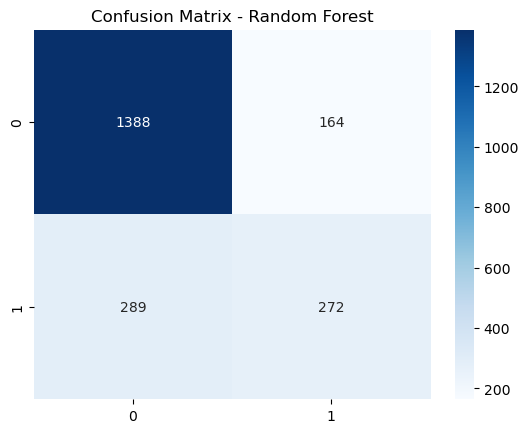


--- Gradient Boosting ---
Accuracy: 0.7983909133932797
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.91      0.87      1552
           1       0.66      0.50      0.57       561

    accuracy                           0.80      2113
   macro avg       0.75      0.70      0.72      2113
weighted avg       0.79      0.80      0.79      2113



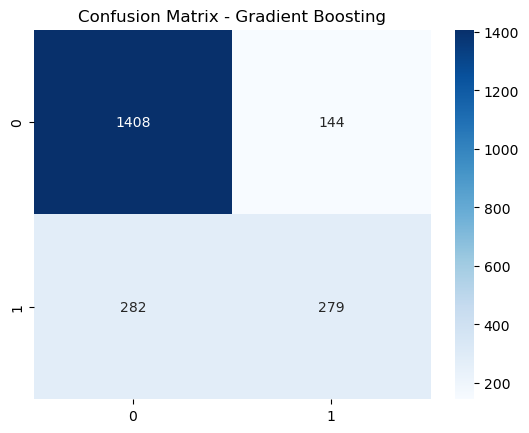

In [8]:
# 8. Evaluate Models Individually
for name, model in {
    "Logistic Regression": logistic_regression,
    "Random Forest": random_forest,
    "Gradient Boosting": gradient_boosting
}.items():
    y_pred = model.predict(X_test)
    print(f"\n--- {name} ---")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.show()

In [9]:
# 9. Model Comparison Table
results = []
for name, model in {
    "Logistic Regression": logistic_regression,
    "Random Forest": random_forest,
    "Gradient Boosting": gradient_boosting
}.items():
    y_pred = model.predict(X_test)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    })
results_df = pd.DataFrame(results)
print("\nModel Comparison:\n", results_df)


Model Comparison:
                  Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.790819   0.620690  0.545455  0.580645
1        Random Forest  0.785613   0.623853  0.484848  0.545637
2    Gradient Boosting  0.798391   0.659574  0.497326  0.567073


In [10]:
# 10. Hyperparameter Tuning (Random Forest Example)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42),
                       param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train, y_train)
print("\nBest Random Forest Params:", grid_rf.best_params_)
print("Best RF Accuracy:", grid_rf.best_score_)


Best Random Forest Params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Best RF Accuracy: 0.8004023311065795


In [11]:
# 11. Cross-Validation
cv_scores = cross_val_score(random_forest, X, y, cv=5, scoring='accuracy')
print("\nRandom Forest CV Accuracy:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())


Random Forest CV Accuracy: [0.79063165 0.78779276 0.77217885 0.79900568 0.796875  ]
Mean CV Accuracy: 0.7892967893089876


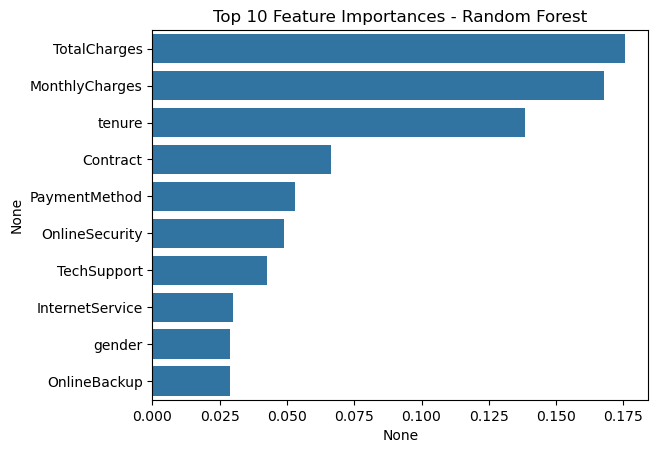

In [12]:
# 12. Feature Importance
feat_imp = pd.Series(random_forest.feature_importances_, index=X_train.columns).sort_values(ascending=False)
sns.barplot(x=feat_imp.head(10), y=feat_imp.head(10).index)
plt.title('Top 10 Feature Importances - Random Forest')
plt.show()

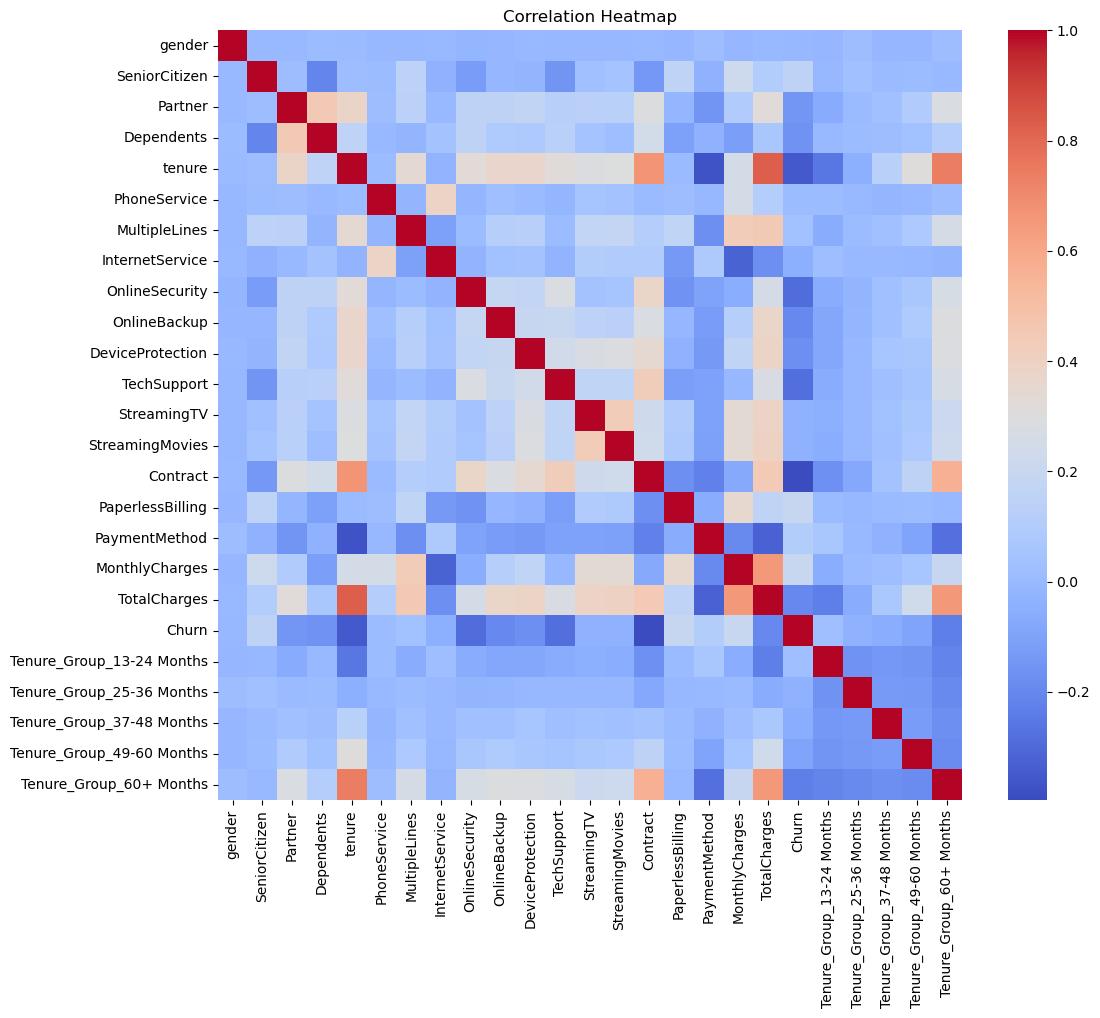

In [13]:
# 13. Correlation Heatmap
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()